**Code for training semantic segmentation models using the SMP library**

Import Libraries

In [1]:
import os
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.optim import lr_scheduler

import pytorch_lightning as pl
import segmentation_models_pytorch as smp

Hyperparameters

In [2]:
MODEL_NAME = "deeplabv3plus" # Available options are: ['unet', 'unetplusplus', 'manet', 'linknet', 'fpn', 'pspnet', 'deeplabv3', 'deeplabv3plus', 'pan', 'upernet', 'segformer', 'dpt']"
ENCODER_NAME = "resnext50_32x4d" 
DEVICE_ID = 2
EPOCHS = 300
LEARNING_RATE = 1e-4
BATCH_SIZE = 128
IMAGE_SIZE = 320
SEED = 42

In [14]:
def read_part_labels(path):
    with open(path) as f:
        labels = [l.strip() for l in f if l.strip()]
        return labels

In [15]:
class PartWholeDataset(Dataset):
    def __init__(self, root, images_dir="aug_images", masks_dir="aug_masks", image_size=320):

        self.images_dir = os.path.join(root, images_dir)
        self.masks_dir = os.path.join(root, masks_dir)
        self.image_size = image_size

        # -------- Labels --------
        self.labels = ["background"] + read_part_labels(
            os.path.join(root, "part_labels.txt")
        )
        self.num_parts = len(self.labels)

        # class folders
        self.classes = sorted(os.listdir(self.images_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        # collect image paths WITH class
        self.samples = []
        for cls in self.classes:
            cls_img_dir = os.path.join(self.images_dir, cls)
            for fname in os.listdir(cls_img_dir):
                if fname.lower().endswith((".jpg", ".png", ".jpeg")):
                    img_path = os.path.join(cls_img_dir, fname)
                    mask_path = os.path.join(self.masks_dir, cls, fname.replace(".jpg", "_m.png"))
                    self.samples.append((img_path, mask_path, self.class_to_idx[cls]))

        self.samples = sorted(self.samples)

        # image transform
        self.img_transform = transforms.Compose([
            transforms.Resize((image_size, image_size),
                              interpolation=InterpolationMode.BILINEAR),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, class_id = self.samples[idx]

        img = Image.open(img_path).convert("RGB")
        img = self.img_transform(img)

        mask = Image.open(mask_path).convert("L")
        mask = mask.resize((self.image_size, self.image_size),
                           resample=Image.NEAREST)
        mask = torch.from_numpy(np.array(mask, dtype=np.int64))

        return img, mask, class_id

In [16]:
# Create Dataset
dataset_path = r'/home/c/choton/beemachine/datasets/Others/CUB_200_2011/'
full_dataset = PartWholeDataset(root=dataset_path, images_dir="aug_images", masks_dir="aug_masks", image_size=IMAGE_SIZE)
torch.manual_seed(SEED)

# Train / Val / Test Split (75:15:10)
n_total = len(full_dataset)
n_train = int(0.75 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_set, val_set, test_set = random_split(full_dataset, [n_train, n_val, n_test])

# DataLoaders
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")
num_classes = len(full_dataset.classes)
print("Number of species:", num_classes)
print("species names:", full_dataset.classes)
print("Number of parts", full_dataset.num_parts)
print("Part labels:", full_dataset.labels)

Train: 8496, Val: 1699, Test: 1133
Number of species: 67
species names: ['001.Black_footed_Albatross', '002.Laysan_Albatross', '003.Sooty_Albatross', '004.Groove_billed_Ani', '005.Crested_Auklet', '006.Least_Auklet', '007.Parakeet_Auklet', '008.Rhinoceros_Auklet', '009.Brewer_Blackbird', '010.Red_winged_Blackbird', '012.Yellow_headed_Blackbird', '013.Bobolink', '014.Indigo_Bunting', '015.Lazuli_Bunting', '017.Cardinal', '018.Spotted_Catbird', '019.Gray_Catbird', '020.Yellow_breasted_Chat', '021.Eastern_Towhee', '022.Chuck_will_Widow', '023.Brandt_Cormorant', '024.Red_faced_Cormorant', '025.Pelagic_Cormorant', '026.Bronzed_Cowbird', '027.Shiny_Cowbird', '028.Brown_Creeper', '029.American_Crow', '030.Fish_Crow', '031.Black_billed_Cuckoo', '033.Yellow_billed_Cuckoo', '034.Gray_crowned_Rosy_Finch', '035.Purple_Finch', '036.Northern_Flicker', '037.Acadian_Flycatcher', '038.Great_Crested_Flycatcher', '039.Least_Flycatcher', '040.Olive_sided_Flycatcher', '041.Scissor_tailed_Flycatcher', '042.

In [17]:
def visualize(**images):
    """Plot images in one row."""
    n = len(images)
    plt.figure(figsize=(16, 5))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.title(" ".join(name.split("_")).title())

        # If it's an image, plot it as RGB
        if name == "image":
            # # Convert CHW to HWC for plotting
            # image = image.transpose(1, 2, 0)
            np_image = np.array(image)
            np_image = np_image.transpose(1, 2, 0)
            plt.imshow(np_image)
        else:
            plt.imshow(image, cmap="tab20")
    plt.show()

Mask shape: torch.Size([320, 320])


/tmp/ipykernel_376115/206719642.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np_image = np.array(image)


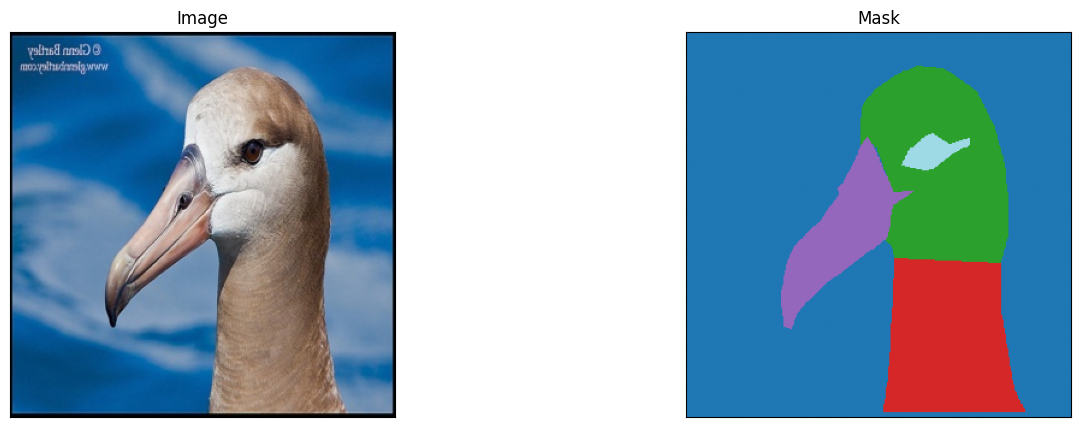

In [18]:
image, mask, _ = full_dataset[0]
print(f"Mask shape: {mask.shape}")
visualize(image=image, mask=mask)

Mask shape: torch.Size([320, 320])


/tmp/ipykernel_376115/206719642.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np_image = np.array(image)


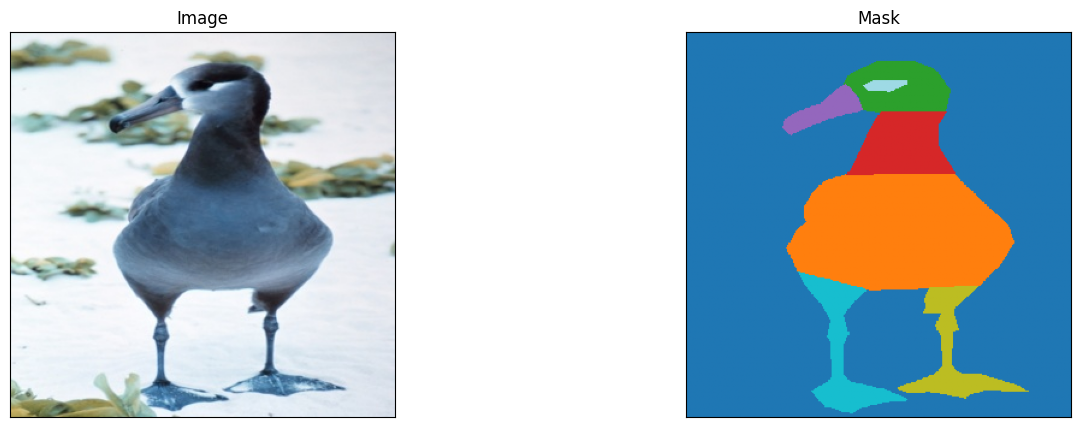

In [19]:
image, mask, _ = full_dataset[30]
print(f"Mask shape: {mask.shape}")
visualize(image=image, mask=mask)

Mask shape: torch.Size([320, 320])


/tmp/ipykernel_376115/206719642.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np_image = np.array(image)


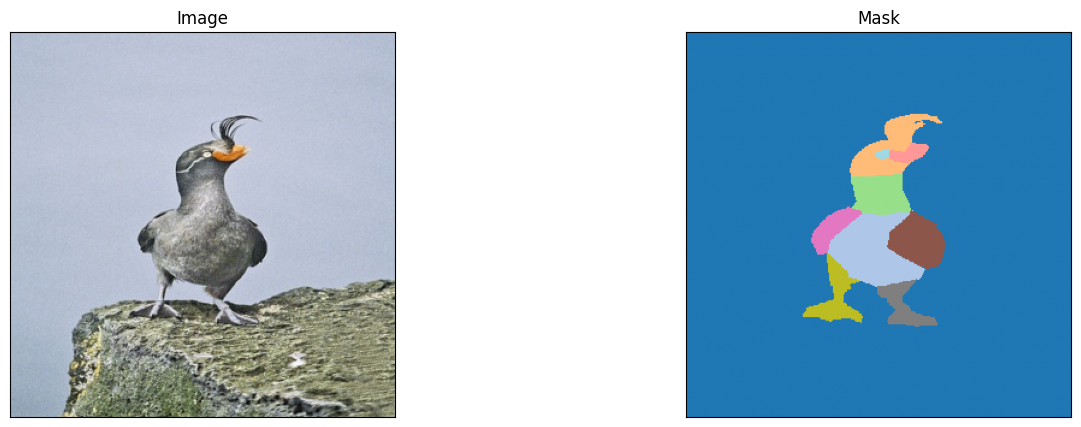

In [21]:
image, mask, _ = full_dataset[786]
print(f"Mask shape: {mask.shape}")
visualize(image=image, mask=mask)

Mask shape: torch.Size([320, 320])


/tmp/ipykernel_376115/206719642.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np_image = np.array(image)


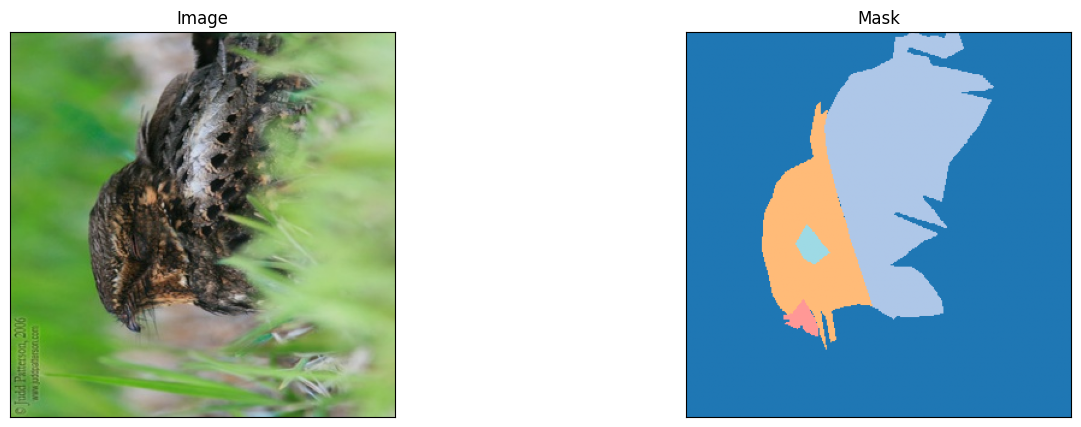

In [22]:
image, mask, _ = full_dataset[3034]
print(f"Mask shape: {mask.shape}")
visualize(image=image, mask=mask)

In [23]:
class CamVidModel(pl.LightningModule):
    def __init__(self, arch, encoder_name, in_channels, out_classes, **kwargs):
        super().__init__()
        self.model = smp.create_model(
            arch,
            encoder_name=encoder_name,
            in_channels=in_channels,
            classes=out_classes,
            **kwargs,
        )

        # Preprocessing parameters for image normalization
        params = smp.encoders.get_preprocessing_params(encoder_name)
        self.number_of_classes = out_classes
        self.register_buffer("std", torch.tensor(params["std"]).view(1, 3, 1, 1))
        self.register_buffer("mean", torch.tensor(params["mean"]).view(1, 3, 1, 1))

        # Loss function for multi-class segmentation
        self.loss_fn = smp.losses.DiceLoss(smp.losses.MULTICLASS_MODE, from_logits=True)

        # Step metrics tracking
        self.training_step_outputs = []
        self.validation_step_outputs = []
        self.test_step_outputs = []

    def forward(self, image):
        # Normalize image
        image = (image - self.mean) / self.std
        mask = self.model(image)
        return mask

    def shared_step(self, batch, stage):
        image, mask, _ = batch

        # Ensure that image dimensions are correct
        assert image.ndim == 4  # [batch_size, channels, H, W]

        # Ensure the mask is a long (index) tensor
        mask = mask.long()

        # Mask shape
        assert mask.ndim == 3  # [batch_size, H, W]

        # Predict mask logits
        logits_mask = self.forward(image)

        assert (
            logits_mask.shape[1] == self.number_of_classes
        )  # [batch_size, number_of_classes, H, W]

        # Ensure the logits mask is contiguous
        logits_mask = logits_mask.contiguous()

        # Compute loss using multi-class Dice loss (pass original mask, not one-hot encoded)
        loss = self.loss_fn(logits_mask, mask)

        # Apply softmax to get probabilities for multi-class segmentation
        prob_mask = logits_mask.softmax(dim=1)

        # Convert probabilities to predicted class labels
        pred_mask = prob_mask.argmax(dim=1)

        # Compute true positives, false positives, false negatives, and true negatives
        tp, fp, fn, tn = smp.metrics.get_stats(
            pred_mask, mask, mode="multiclass", num_classes=self.number_of_classes
        )

        return {
            "loss": loss,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
        }

    def shared_epoch_end(self, outputs, stage):
        # Aggregate step metrics
        tp = torch.cat([x["tp"] for x in outputs])
        fp = torch.cat([x["fp"] for x in outputs])
        fn = torch.cat([x["fn"] for x in outputs])
        tn = torch.cat([x["tn"] for x in outputs])

        # Per-image IoU and dataset IoU calculations
        per_image_iou = smp.metrics.iou_score(
            tp, fp, fn, tn, reduction="micro-imagewise"
        )
        dataset_iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro")

        metrics = {
            f"{stage}_per_image_iou": per_image_iou,
            f"{stage}_dataset_iou": dataset_iou,
        }

        self.log_dict(metrics, prog_bar=True)

    def training_step(self, batch, batch_idx):
        train_loss_info = self.shared_step(batch, "train")
        self.training_step_outputs.append(train_loss_info)
        return train_loss_info

    def on_train_epoch_end(self):
        self.shared_epoch_end(self.training_step_outputs, "train")
        self.training_step_outputs.clear()

    def validation_step(self, batch, batch_idx):
        valid_loss_info = self.shared_step(batch, "valid")
        self.validation_step_outputs.append(valid_loss_info)
        return valid_loss_info

    def on_validation_epoch_end(self):
        self.shared_epoch_end(self.validation_step_outputs, "valid")
        self.validation_step_outputs.clear()

    def test_step(self, batch, batch_idx):
        test_loss_info = self.shared_step(batch, "test")
        self.test_step_outputs.append(test_loss_info)
        return test_loss_info

    def on_test_epoch_end(self):
        self.shared_epoch_end(self.test_step_outputs, "test")
        self.test_step_outputs.clear()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=2e-4)
        scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "epoch",
                "frequency": 1,
            },
        }

In [7]:
model = CamVidModel(MODEL_NAME, ENCODER_NAME, in_channels=3, out_classes=full_dataset.num_parts)

In [8]:
trainer = pl.Trainer(max_epochs=EPOCHS, log_every_n_steps=1, devices=[0,1,2,3,4,5,6,7])

trainer.fit(
    model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/result.py:434: It is recommended to use `self.log('valid_per_image_iou', ..., sync_dist=True)` when logging on epoch level in distributed setting to accumulate the metric across devices.
/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/result.py:434: It is recommended to use `self.log('valid_dataset_iou', ..., sync_dist=True)` when logging on epoch level in distributed setting to accumulate the metric across devices.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=300` reached.
